In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# # 炭素のrunをマージ
# # 各ランを読み込み、辞書に追加
# # ランナンバーも追加
# # GRX, GRY, LASX, LASYが-9999も削除

# run_list = [2038, 2039]
# dfs = {}  # 空の辞書を作成

# for run in run_list:
#     file_name = f'run{run}_none.csv'
#     df = pd.read_csv(file_name)

#     xdp=df['GRX']
#     adp=df['GRA']
#     ydp=df['GRY']
#     bdp=df['GRB']
#     GRQ2=df['GRQ2charge']

#     df = df[
#         (xdp!=-9999) & (ydp!=-9999)
#     ]

#     LASX = df['LASX']
#     LASA = df['LASA']
#     LASY = df['LASY']
#     LASB = df['LASB']

#     df = df[
#         (LASX!=-9999) & (LASY!=-9999)
#     ]

#     df.insert(0, 'run', run)

#     # 辞書に格納 (キーをRun番号にする)
#     dfs[run] = df

# # 呼び出すときは dfs[2025] のようにします
# # print(dfs[2025].head())


# # データを読み込み、すべての列を数値型に変換
# data = pd.read_csv("run2025_none.csv")


# GRtiming=data['GRQ2timing']
# LAStiming=data['LASQ1timing']
# TDiff=LAStiming-GRtiming

In [3]:
# # dfsを結合
# # (ここはすでにdfsが作成されている前提です)
# # dfs = {2025: df_2025, 2005: df_2005, ...} 

# # 1. 結合用のリストを作成
# list_of_dfs = []

# # 2. 辞書から一つずつ取り出して処理
# for run_num, df in dfs.items():
#     # 元のデータを壊さないようにコピー
#     df_temp = df.copy()
    
#     # リストに追加
#     list_of_dfs.append(df_temp)

# # 3. 全てを縦に結合 (concat)
# correct = pd.concat(list_of_dfs, ignore_index=True)

In [4]:
correct = pd.read_csv("Pb_labeled.csv")

In [5]:
GRQ2_track = correct['GRQ2charge']

TOT=correct['LASTOT']
Lx=correct['LASX']
GRtiming=correct['GRQ2timing']
LAStiming=correct['LASQ1timing']
TDiff=LAStiming-GRtiming

PID_gated = correct[
    (GRQ2_track > 213.276 - 21.194 * 5) & (GRQ2_track < 213.276 + 21.194 * 5) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)>140) & (TOT+0.0430496*Lx-1.3842e-5*(Lx**2)<170)
]

TOT_alpha=PID_gated['LASTOT']
Lx_alpha=PID_gated['LASX']
GRtiming_alpha=PID_gated['GRQ2timing']
LAStiming_alpha=PID_gated['LASQ1timing']
TDiff_alpha=LAStiming_alpha-GRtiming_alpha

Text(0, 0.5, 'counts')

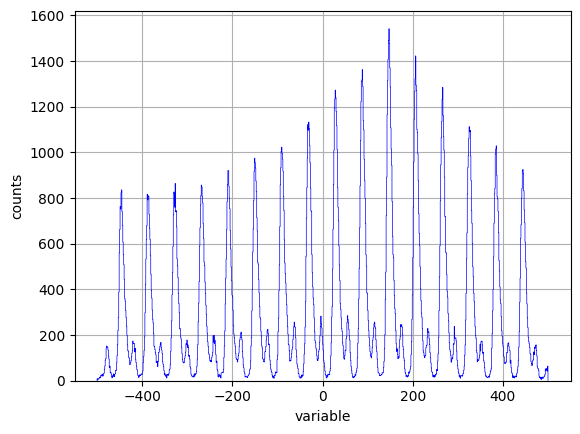

In [6]:
#アルファゲートかけてコインシデンスとる
#綺麗にアクシデンタル減らせたのを確認

import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
variable=TDiff_alpha
#hist range
range_min=-500
range_max=500
#bin width
x_bin_width=1
####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅を10に設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('variable')
ax.set_ylabel('counts')

In [7]:
# a1 = PID_gated[
#     (-430 < TDiff_alpha) & (TDiff_alpha < -370)
# ]
# # a2 = alpha_gated[
# #     (-370 < TDiff_alpha) & (TDiff_alpha < -310)
# # ]
# # a3 = alpha_gated[
# #     (-310 < TDiff_alpha) & (TDiff_alpha < -250)
# # ]
# # a4 = alpha_gated[
# #     (-250 < TDiff_alpha) & (TDiff_alpha < -190)
# # ]
# # a5 = alpha_gated[
# #     (-190 < TDiff_alpha) & (TDiff_alpha < -130)
# # ]
# # a6 = alpha_gated[
# #     (-130 < TDiff_alpha) & (TDiff_alpha < -70)
# # ]
# # a7 = alpha_gated[
# #     (-70 < TDiff_alpha) & (TDiff_alpha < -10)
# # ]
# # a8 = alpha_gated[
# #     (-10 < TDiff_alpha) & (TDiff_alpha < 50)
# # ]
# # a9 = alpha_gated[
# #     (50 < TDiff_alpha) & (TDiff_alpha < 110)
# # ]
# # a10 = alpha_gated[
# #     (110 < TDiff_alpha) & (TDiff_alpha < 170)
# # ]
# # a11 = alpha_gated[
# #     (170 < TDiff_alpha) & (TDiff_alpha < 230)
# # ]

# #　コインシデンスとったやつのみ抽出
# GRX_acc = a1['GRX']
# LASX_acc = a1['LASX']
# LASA_acc = a1['LASA']

# #Tp, Tαを再構成
# Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
# T_alpha_acc = 0.02746 * LASX_acc + 63.804
# LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
# T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804


# #input
# variable = 392 - Tp_acc - T_alpha_acc_f
# #hist range
# range_min=-500
# range_max=500
# #bin width
# x_bin_width=3
# ####################################################

# fig=plt.figure()
# ax=fig.add_subplot(111)

# bin_width = x_bin_width # ビン幅を10に設定
# bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
# bin_counts, bin_edges = np.histogram(variable, bins=bins)
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

# ax.hist(variable, bins=bins,histtype='step', color='blue', linewidth=0.5)
# ax.set_xlim(-200, 150)
# # ax.set_ylim(0, 10)
# ax.grid()
# ax.set_xlabel('variable')
# ax.set_ylabel('counts')

In [8]:
#コインシデンスゲート
true = PID_gated[
    (TDiff_alpha >= 50) & (TDiff_alpha < 110)
]

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- 物理量の計算 ---
GRX_acc = true['GRX']
LASX_acc = true['LASX']
LASA_acc = true['LASA']

# Tp, Tαの計算
Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
# Variable (S_alpha)
variable = 392 - Tp_acc - T_alpha_acc_f

# --- ヒストグラム作成 (カウントのみ取得) ---
counts2, _ = np.histogram(variable, bins=bins)
    
# リストに追加
hist_list2 = []
hist_list2.append(counts2)

In [9]:
hist_list2

[array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
          0,   0,   1,   0,   0,   0,   0,   0,   2,   0,   0,   0,   0,
          0,   1,   1,   0,   0,   1,   1,   1,   2,   0,   3,   0,   0,
          0,   1,   1,   2,   0,   0,   0,   0,   0,   1,   0,   3,   0,
          0,   1,   0,   0,   1,   2,   0,   0,   1,   0,   0,   1,   0,
          1,   1,   0,   0,   0,   1,   0,   1,   8,  15,  32,  53,  61,
         78,  89, 121, 145, 169, 181, 189, 227, 224, 281, 308, 311, 351,
        416, 425, 455, 487, 504, 509, 588, 605, 672, 681, 689, 675, 727,
        684, 692, 629, 657, 639, 651, 630, 588, 526, 537, 530, 432, 444,
        444, 427, 373, 374, 349, 340, 304, 302, 264, 220, 199, 176, 176,
        108, 116, 100,  66,  49,  53,  29,  18,   0,   1,   2,   0,   2,
          0,   4,   1,   0,   0,   0,   5,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,   1,
          0,   0,   0,   0,   0,   0,   0,   0,   0

Number of stacked windows: 5


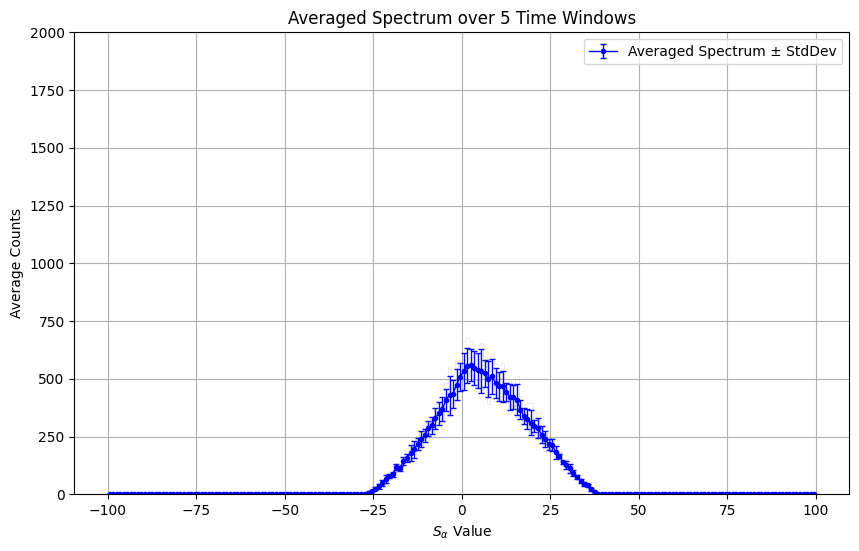

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 設定パラメータ ---
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = -250      # 開始位置
end_tdiff = 50         # 終了位置

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ヒストグラムデータを格納するリスト
hist_list = []

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)

# --- 3. 平均と標準偏差の計算 ---

# リストをNumPy配列（行列）に変換
# 行: 各TDiffウィンドウ, 列: 各ビン
hist_matrix = np.array(hist_list)

# サンプル数（ウィンドウの数）
N_samples = hist_matrix.shape[0]

print(f"Number of stacked windows: {N_samples}")

if N_samples > 0:
    # 縦方向 (axis=0) に計算
    
    # 平均スペクトル
    mean_spectrum = np.mean(hist_matrix, axis=0)
    
    # 標準偏差 (Standard Deviation)
    # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
    std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # エラーバー付きで平均スペクトルをプロット
    # yerr に標準偏差を指定することで、ばらつきを表示
    ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
                fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
                label='Averaged Spectrum ± StdDev')
    
    # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
    for i in range(N_samples):
        ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

    ax.set_xlabel('$S_\\alpha$ Value')
    ax.set_ylabel('Average Counts')
    ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
    ax.set_ylim(0, 2000)
    ax.grid(True)
    ax.legend()
    
    plt.show()

else:
    print("No valid data found in the specified ranges.")

In [11]:
counts

array([  0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   1,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
         0,   0,   0,   0,   0,   1,   0,   0,   1,   1,   1,   3,   1,
         0,   0,   1,   0,   0,   0,   1,   2,   2,   2,   2,   0,   0,
         0,   1,   1,   0,   2,   2,   1,   2,   0,   0,   0,   2,   1,
         0,   1,   0,   1,   0,   0,   0,   1,   8,  18,  31,  42,  68,
        90,  88,  97, 130, 128, 160, 187, 208, 233, 238, 270, 294, 315,
       336, 389, 409, 437, 482, 553, 522, 578, 568, 660, 678, 664, 647,
       645, 655, 599, 585, 608, 568, 562, 568, 501, 489, 470, 512, 427,
       390, 397, 395, 332, 356, 309, 272, 246, 245, 219, 182, 143, 154,
       126, 110,  80,  59,  56,  46,  30,   8,   1,   0,   0,   1,   2,
         0,   2,   0,   0,   0,   1,   0,   0,   0,   0,   1,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [12]:
len(hist_list)

5

Number of stacked windows: 10


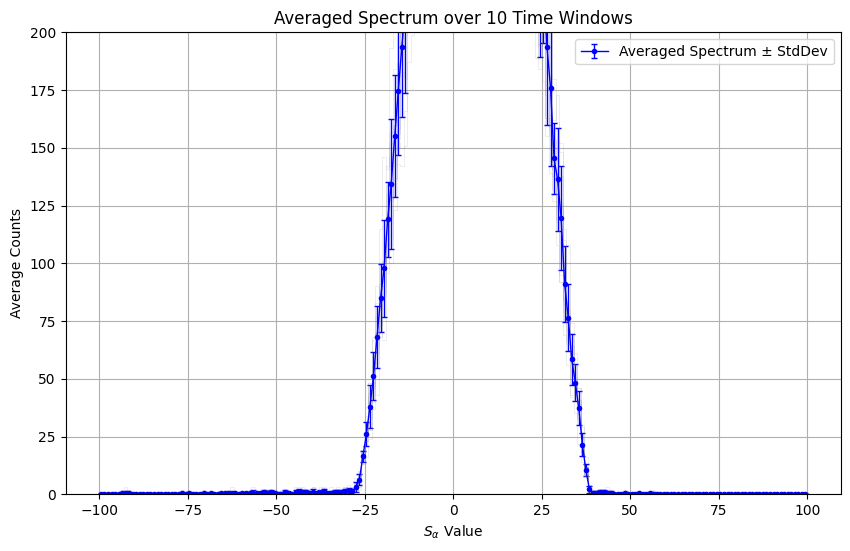

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 設定パラメータ ---
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = 110      # 開始位置
end_tdiff = 410         # 終了位置

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ヒストグラムデータを格納するリスト

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)

# --- 3. 平均と標準偏差の計算 ---

# リストをNumPy配列（行列）に変換
# 行: 各TDiffウィンドウ, 列: 各ビン
hist_matrix = np.array(hist_list)

# サンプル数（ウィンドウの数）
N_samples = hist_matrix.shape[0]

print(f"Number of stacked windows: {N_samples}")

if N_samples > 0:
    # 縦方向 (axis=0) に計算
    
    # 平均スペクトル
    mean_spectrum = np.mean(hist_matrix, axis=0)
    
    # 標準偏差 (Standard Deviation)
    # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
    std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

    # --- 4. プロット ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # エラーバー付きで平均スペクトルをプロット
    # yerr に標準偏差を指定することで、ばらつきを表示
    ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
                fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
                label='Averaged Spectrum ± StdDev')
    
    # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
    for i in range(N_samples):
        ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.2, linewidth=0.5)

    ax.set_xlabel('$S_\\alpha$ Value')
    ax.set_ylabel('Average Counts')
    ax.set_title(f'Averaged Spectrum over {N_samples} Time Windows')
    ax.set_ylim(0, 200)
    ax.grid(True)
    ax.legend()
    
    plt.show()

else:
    print("No valid data found in the specified ranges.")

In [14]:
len(hist_list)

10

In [15]:
hist_list

[array([  0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          1,   0,   0,   0,   1,   0,   0,   0,   0,   0,   1,   0,   0,
          0,   0,   0,   0,   0,   0,   1,   0,   1,   0,   1,   0,   1,
          0,   1,   0,   0,   0,   0,   1,   2,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   1,   1,   0,   3,   0,   0,   1,   0,
          0,   0,   0,   0,   3,   1,   1,   3,   6,  19,  23,  24,  48,
         43,  74,  67, 103, 120, 142, 143, 142, 166, 187, 199, 232, 243,
        258, 297, 292, 311, 361, 334, 367, 403, 424, 446, 493, 490, 475,
        448, 455, 465, 393, 426, 404, 410, 401, 399, 346, 398, 333, 322,
        299, 280, 304, 263, 238, 220, 189, 195, 179, 163, 158, 127, 108,
         92,  82,  71,  43,  47,  41,  21,   9,   4,   1,   0,   1,   2,
          1,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   1,
          0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0

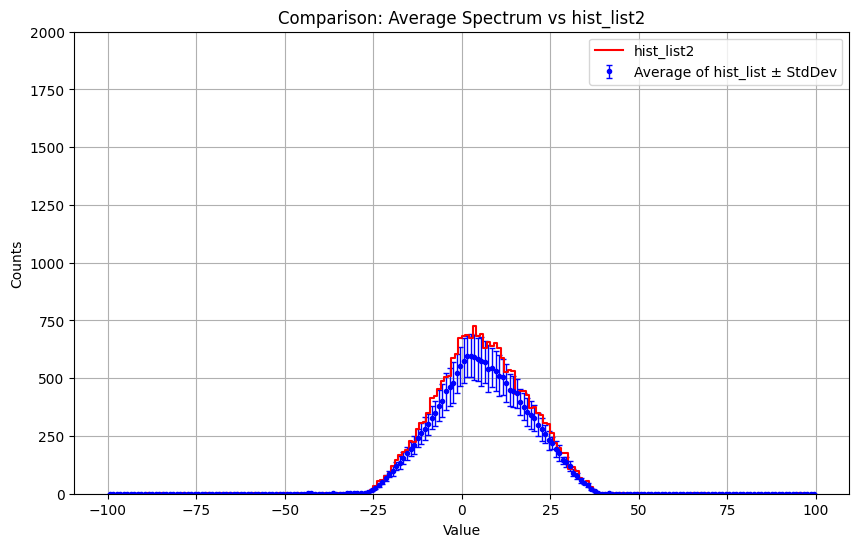

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# --- 事前準備 (hist_listとhist_list2は既に作成されていると仮定) ---
# hist_list: [array([counts...]), array([counts...]), ...] (複数のヒストグラム)
# hist_list2: array([counts...]) (単一のヒストグラムデータ)
# bins: ビンの境界配列

# ビンの中心を計算（プロットのx軸用）
bin_centers = (bins[:-1] + bins[1:]) / 2

# --- 1. hist_list の平均と標準偏差の計算 ---
hist_matrix = np.array(hist_list)

# 平均 (axis=0 で縦方向に平均)
mean_spectrum = np.mean(hist_matrix, axis=0)

# 標準偏差 (ばらつき)
std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

# --- 2. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# (A) hist_list の平均スペクトルをエラーバー付きでプロット
ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='blue',
            label='Average of hist_list ± StdDev')

# (B) hist_list2 をプロット
# hist_list2 がリストに入っている場合は hist_list2[0]、配列ならそのまま使います
# ここでは配列(1次元)として扱います
data_to_plot = np.array(hist_list2).flatten() #念のため1次元化

ax.step(bin_centers, data_to_plot, where='mid', color='red', linewidth=1.5, 
        label='hist_list2')

# グラフの装飾
ax.set_xlabel('Value')
ax.set_ylabel('Counts')
ax.set_title('Comparison: Average Spectrum vs hist_list2')
ax.set_ylim(0, 2000)
ax.grid(True)
ax.legend()

plt.show()

In [17]:
bin_centers

array([-99.5, -98.5, -97.5, -96.5, -95.5, -94.5, -93.5, -92.5, -91.5,
       -90.5, -89.5, -88.5, -87.5, -86.5, -85.5, -84.5, -83.5, -82.5,
       -81.5, -80.5, -79.5, -78.5, -77.5, -76.5, -75.5, -74.5, -73.5,
       -72.5, -71.5, -70.5, -69.5, -68.5, -67.5, -66.5, -65.5, -64.5,
       -63.5, -62.5, -61.5, -60.5, -59.5, -58.5, -57.5, -56.5, -55.5,
       -54.5, -53.5, -52.5, -51.5, -50.5, -49.5, -48.5, -47.5, -46.5,
       -45.5, -44.5, -43.5, -42.5, -41.5, -40.5, -39.5, -38.5, -37.5,
       -36.5, -35.5, -34.5, -33.5, -32.5, -31.5, -30.5, -29.5, -28.5,
       -27.5, -26.5, -25.5, -24.5, -23.5, -22.5, -21.5, -20.5, -19.5,
       -18.5, -17.5, -16.5, -15.5, -14.5, -13.5, -12.5, -11.5, -10.5,
        -9.5,  -8.5,  -7.5,  -6.5,  -5.5,  -4.5,  -3.5,  -2.5,  -1.5,
        -0.5,   0.5,   1.5,   2.5,   3.5,   4.5,   5.5,   6.5,   7.5,
         8.5,   9.5,  10.5,  11.5,  12.5,  13.5,  14.5,  15.5,  16.5,
        17.5,  18.5,  19.5,  20.5,  21.5,  22.5,  23.5,  24.5,  25.5,
        26.5,  27.5,

In [18]:
data_to_plot

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         0,   0,   1,   0,   0,   0,   0,   0,   2,   0,   0,   0,   0,
         0,   1,   1,   0,   0,   1,   1,   1,   2,   0,   3,   0,   0,
         0,   1,   1,   2,   0,   0,   0,   0,   0,   1,   0,   3,   0,
         0,   1,   0,   0,   1,   2,   0,   0,   1,   0,   0,   1,   0,
         1,   1,   0,   0,   0,   1,   0,   1,   8,  15,  32,  53,  61,
        78,  89, 121, 145, 169, 181, 189, 227, 224, 281, 308, 311, 351,
       416, 425, 455, 487, 504, 509, 588, 605, 672, 681, 689, 675, 727,
       684, 692, 629, 657, 639, 651, 630, 588, 526, 537, 530, 432, 444,
       444, 427, 373, 374, 349, 340, 304, 302, 264, 220, 199, 176, 176,
       108, 116, 100,  66,  49,  53,  29,  18,   0,   1,   2,   0,   2,
         0,   4,   1,   0,   0,   0,   5,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,   1,   1,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

[array([  0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         1,   0,   0,   0,   1,   0,   0,   0,   0,   0,   1,   0,   0,
         0,   0,   0,   0,   0,   0,   1,   0,   1,   0,   1,   0,   1,
         0,   1,   0,   0,   0,   0,   1,   2,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   1,   1,   0,   3,   0,   0,   1,   0,
         0,   0,   0,   0,   3,   1,   1,   3,   6,  19,  23,  24,  48,
        43,  74,  67, 103, 120, 142, 143, 142, 166, 187, 199, 232, 243,
       258, 297, 292, 311, 361, 334, 367, 403, 424, 446, 493, 490, 475,
       448, 455, 465, 393, 426, 404, 410, 401, 399, 346, 398, 333, 322,
       299, 280, 304, 263, 238, 220, 189, 195, 179, 163, 158, 127, 108,
        92,  82,  71,  43,  47,  41,  21,   9,   4,   1,   0,   1,   2,
         1,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0,   1,
         0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  

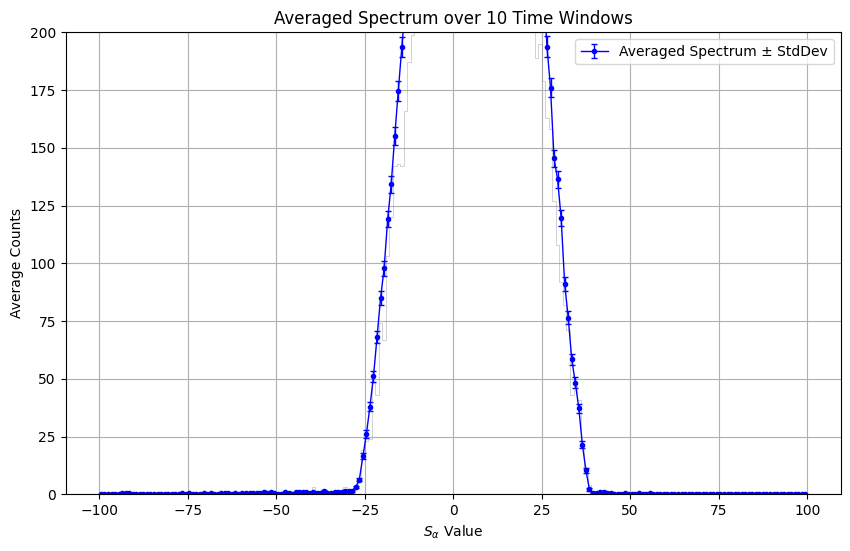

No valid data found in the specified ranges.


In [19]:
# アクシデンタルの誤差を再考
# 誤差棒の大きさはfrac{\sqrtN}{10}です

# -250から50まで
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 設定パラメータ ---
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = -250      # 開始位置
end_tdiff = 50         # 終了位置

# ヒストグラムの設定（全てのウィンドウで共通にする必要があります）
hist_min = -100
hist_max = 100
bin_width = 1
bins = np.arange(hist_min, hist_max + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2

# ヒストグラムデータを格納するリスト
hist_list = []


#-250から50
# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)



#110から410
window_width = 60       # TDiffのウィンドウ幅
start_tdiff = 110      # 開始位置
end_tdiff = 410         # 終了位置

# --- 2. ループ処理で各範囲のヒストグラムを取得 ---
for t_start in range(start_tdiff, end_tdiff, window_width):
    t_end = t_start + window_width
    
    # データの抽出
    subset = PID_gated[
        (TDiff_alpha >= t_start) & (TDiff_alpha < t_end)
    ]
    
    # データが少なすぎる場合はノイズになるのでスキップ（必要に応じて調整）
    if len(subset) < 10:
        continue

    # --- 物理量の計算 ---
    GRX_acc = subset['GRX']
    LASX_acc = subset['LASX']
    LASA_acc = subset['LASA']

    # Tp, Tαの計算
    Tp_acc = (((GRX_acc * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    LASX_acc_f = LASA_acc * (-2.57 * Tp_acc + 1274.57) + LASX_acc
    T_alpha_acc_f = 0.02746 * LASX_acc_f + 63.804
    
    # Variable (S_alpha)
    variable = 392 - Tp_acc - T_alpha_acc_f

    # --- ヒストグラム作成 (カウントのみ取得) ---
    counts, _ = np.histogram(variable, bins=bins)
    
    # リストに追加
    hist_list.append(counts)

print(hist_list)



# --- 3. 平均と標準偏差の計算 ---

# リストをNumPy配列（行列）に変換
# 行: 各TDiffウィンドウ, 列: 各ビン
hist_matrix = np.array(hist_list)

# # サンプル数（ウィンドウの数）
# N_samples = hist_matrix.shape[0]

print(f"Number of stacked windows: {N_samples}")


# 縦方向 (axis=0) に計算
    
# # 平均スペクトル
mean_spectrum = np.mean(hist_matrix, axis=0)
    
# # 標準偏差 (Standard Deviation)
# # ddof=1 は不偏標準偏差（サンプル数が少ない場合に推奨）
# std_spectrum = np.std(hist_matrix, axis=0, ddof=1)

summed_spectrum = np.sum(hist_matrix, axis=0)
error = np.sqrt(summed_spectrum) / 10

# --- 4. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))
    
    # エラーバー付きで平均スペクトルをプロット
    # yerr に標準偏差を指定することで、ばらつきを表示
    # ax.errorbar(bin_centers, mean_spectrum, yerr=std_spectrum, 
    #             fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
    #             label='Averaged Spectrum ± StdDev')

ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
                fmt='-o', markersize=3, capsize=2, linewidth=1, color='blue',
                label='Averaged Spectrum ± StdDev')
    
    # 参考までに個別のスペクトルを薄く表示（ばらつき具合を目視するため）
for i in range(10):
    ax.step(bin_centers, hist_matrix[i], where='mid', color='gray', alpha=0.5, linewidth=0.5)

    ax.set_xlabel('$S_\\alpha$ Value')
    ax.set_ylabel('Average Counts')
    ax.set_title(f'Averaged Spectrum over 10 Time Windows')
    ax.set_ylim(0, 200)
    ax.grid(True)
    ax.legend()
    
    plt.show()

else:
    print("No valid data found in the specified ranges.")



# # hist_matrix = np.array(hist_list) までは同じ

# # 1. サンプル数（積み上げたヒストグラムの数）を取得
# N_samples = hist_matrix.shape[0]

# # 2. 平均スペクトルの計算
# mean_spectrum = np.mean(hist_matrix, axis=0)

# # 3. 誤差の計算 (ポアソン統計に基づく)
# # 各ビンの「合計カウント」を計算
# sum_spectrum = np.sum(hist_matrix, axis=0)

# # 誤差 = ルート(合計) / N_samples
# # これにより、平均操作に伴う誤差伝播が正しく計算されます
# poisson_error = np.sqrt(sum_spectrum) / N_samples

# # --- プロット ---
# fig, ax = plt.subplots(figsize=(10, 6))

# ax.errorbar(bin_centers, mean_spectrum, yerr=poisson_error, 
#             fmt='o', markersize=3, capsize=2, linewidth=1, color='blue',
#             label='Average Spectrum (Poisson Error)')

# ax.set_xlabel('Value')
# ax.set_ylabel('Average Counts')
# ax.set_title('Average Spectrum with Poisson Error')
# ax.grid(True)
# ax.legend()

plt.show()

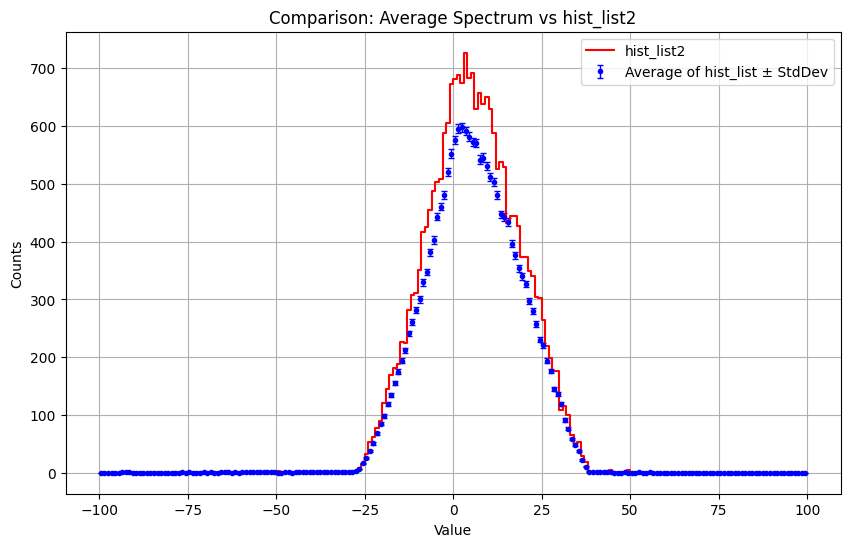

In [20]:
# hist1とhist2を同時にプロット
import numpy as np
import matplotlib.pyplot as plt

# --- 事前準備 (hist_listとhist_list2は既に作成されていると仮定) ---
# hist_list: [array([counts...]), array([counts...]), ...] (複数のヒストグラム)
# hist_list2: array([counts...]) (単一のヒストグラムデータ)
# bins: ビンの境界配列

# ビンの中心を計算（プロットのx軸用）
bin_centers = (bins[:-1] + bins[1:]) / 2




# --- 2. プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

# (A) hist_list の平均スペクトルをエラーバー付きでプロット
ax.errorbar(bin_centers, mean_spectrum, yerr=error, 
            fmt='o', markersize=3, capsize=2, linewidth=1, color='blue',
            label='Average of hist_list ± StdDev')

# (B) hist_list2 をプロット
# hist_list2 がリストに入っている場合は hist_list2[0]、配列ならそのまま使います
# ここでは配列(1次元)として扱います
data_to_plot = np.array(hist_list2).flatten() #念のため1次元化

ax.step(bin_centers, data_to_plot, where='mid', color='red', linewidth=1.5, 
        label='hist_list2')

# グラフの装飾
ax.set_xlabel('Value')
ax.set_ylabel('Counts')
ax.set_title('Comparison: Average Spectrum vs hist_list2')
ax.grid(True)
ax.legend()

plt.show()